# Model 5 — MobileNetV2 Transfer Learning

**Group**: Group 14  
**Members**: *(update with real names)*  
**Model owner**: P5  
**Architecture**: MobileNetV2 (ImageNet weights, include_top=False) + GlobalAveragePooling2D + Dense(128) + Dropout(0.3) + sigmoid  
**Dataset**: NIH Malaria Cell Images — Parasitized vs Uninfected  
**Date**: June 2026

---
This notebook applies MobileNetV2 to malaria cell binary classification via transfer learning.  
MobileNetV2 uses depthwise separable convolutions and inverted residuals, making it significantly  
lighter than VGG16 or ResNet50 while remaining competitive in accuracy — ideal for deployment  
in resource-constrained clinical settings. The `alpha` width multiplier is explored as an  
architectural variable, and Experiment 7 compares against EfficientNetB0 as an alternative base.

## 1. Environment Setup
Install dependencies, set all random seeds for reproducibility, and verify GPU availability.

In [1]:
!pip install -q kagglehub tqdm

import os, sys, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus if gpus else 'None — training on CPU')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset Download
Download the NIH Malaria dataset via `kagglehub`. The inner `cell_images` folder is targeted explicitly to avoid the nested directory conflict on platforms such as Deepnote.

In [2]:
import kagglehub

path = kagglehub.dataset_download('iarunava/cell-images-for-detecting-malaria')
print('Downloaded to:', path)

# Skip outer cell_images/ folder — only match directory containing BOTH class folders and nothing else
DATA_DIR = None
for root, dirs, _ in os.walk(path):
    if 'Parasitized' in dirs and 'Uninfected' in dirs and 'cell_images' not in dirs:
        DATA_DIR = root
        break

assert DATA_DIR is not None, 'Could not locate Parasitized/Uninfected folders'
print('DATA_DIR:', DATA_DIR)
print('Parasitized images:', len(os.listdir(os.path.join(DATA_DIR, 'Parasitized'))))
print('Uninfected images: ', len(os.listdir(os.path.join(DATA_DIR, 'Uninfected'))))

Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
Downloaded to: /kaggle/input/cell-images-for-detecting-malaria
DATA_DIR: /kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images
Parasitized images: 13780
Uninfected images:  13780


## 3. Shared Helper Functions
All helper functions are defined inline — this notebook runs independently on any platform without needing `utils.py`.  
**Note**: MobileNetV2 requires raw pixel values [0, 255] — `mobilenet_v2.preprocess_input` is applied inside the model, so `load_dataset` is called with `normalise=False`.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
)

# ── Constants
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
CLASS_NAMES = ['Parasitized', 'Uninfected']
TRAIN_SPLIT = 0.80
VAL_SPLIT   = 0.10
TEST_SPLIT  = 0.10

# Fraction of full dataset used — same across all 5 models for fair comparison
DATASET_FRACTION = 0.2

os.makedirs('figures',     exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

# ── Augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='data_augmentation')

# ── Dataset loader
def load_dataset(data_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                 normalise=False, fraction=1.0):
    """
    fraction: float in (0, 1] — proportion of full dataset to use.
    All 5 models use the same DATASET_FRACTION for fair cross-model comparison.
    normalise: True for custom CNNs (/255); False for pretrained models (preprocess_input inside model).
    """
    full_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='binary',
        class_names=CLASS_NAMES,
        image_size=image_size,
        batch_size=None,
        shuffle=True,
        seed=SEED,
    )
    total = sum(1 for _ in full_ds)
    use   = int(total * fraction) if fraction < 1.0 else total
    if fraction < 1.0:
        full_ds = full_ds.take(use)
        print(f'Using {use}/{total} images ({fraction*100:.0f}% of dataset)')

    n_train   = int(use * TRAIN_SPLIT)
    n_val     = int(use * VAL_SPLIT)
    train_ds  = full_ds.take(n_train)
    remaining = full_ds.skip(n_train)
    val_ds    = remaining.take(n_val)
    test_ds   = remaining.skip(n_val)
    AUTOTUNE  = tf.data.AUTOTUNE
    cast_fn = (lambda img, lbl: (tf.cast(img, tf.float32) / 255.0, lbl)) if normalise \
              else (lambda img, lbl: (tf.cast(img, tf.float32), lbl))
    train_ds = (train_ds.map(cast_fn, num_parallel_calls=AUTOTUNE)
                .cache().shuffle(1000, seed=SEED).batch(batch_size).prefetch(AUTOTUNE))
    val_ds   = (val_ds.map(cast_fn, num_parallel_calls=AUTOTUNE)
                .cache().batch(batch_size).prefetch(AUTOTUNE))
    test_ds  = (test_ds.map(cast_fn, num_parallel_calls=AUTOTUNE)
                .cache().batch(batch_size).prefetch(AUTOTUNE))
    return train_ds, val_ds, test_ds

# ── Metrics
def evaluate_model(model, test_ds):
    y_true, y_pred_prob = [], []
    for images, labels in test_ds:
        preds = model(images, training=False).numpy().flatten()
        y_pred_prob.extend(preds)
        y_true.extend(labels.numpy().flatten())
    y_true      = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred      = (y_pred_prob >= 0.5).astype(int)
    return {
        'accuracy':  round(accuracy_score(y_true, y_pred),     4),
        'precision': round(precision_score(y_true, y_pred),    4),
        'recall':    round(recall_score(y_true, y_pred),       4),
        'f1':        round(f1_score(y_true, y_pred),           4),
        'auc':       round(roc_auc_score(y_true, y_pred_prob), 4),
        'y_true':    y_true,
        'y_pred':    y_pred,
        'y_prob':    y_pred_prob,
    }

# ── Learning curves
def plot_learning_curves(history, experiment_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Learning curves — {experiment_name}', fontsize=14, fontweight='bold')
    axes[0].plot(history.history['loss'],     label='Train loss',     linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val loss',       linewidth=2, linestyle='--')
    axes[0].set_title('Loss over epochs'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['accuracy'],     label='Train accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val accuracy',   linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy over epochs'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    final_train = history.history['accuracy'][-1]
    final_val   = history.history['val_accuracy'][-1]
    gap = final_train - final_val
    if gap > 0.05:
        print(f'Overfitting detected: train {final_train:.3f} vs val {final_val:.3f} (gap={gap:.3f})')
    elif gap < -0.02:
        print(f'Underfitting detected: train {final_train:.3f} vs val {final_val:.3f}')
    else:
        print(f'Good fit: train {final_train:.3f} vs val {final_val:.3f} (gap={gap:.3f})')

# ── Confusion matrix
def plot_confusion_matrix(metrics_dict, class_names, experiment_name, save_path=None):
    cm  = confusion_matrix(metrics_dict['y_true'], metrics_dict['y_pred'])
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion matrix — {experiment_name}', fontsize=13, fontweight='bold', pad=14)
    ax.set_ylabel('True label', fontsize=11); ax.set_xlabel('Predicted label', fontsize=11)
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.12,
            f'TP={tp}  TN={tn}  FP={fp}  FN={fn}  |  Sensitivity={tp/(tp+fn):.3f}  Specificity={tn/(tn+fp):.3f}',
            ha='center', va='top', transform=ax.transAxes, fontsize=10, color='dimgray')
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ── ROC curve
def plot_roc_curve(metrics_dict, experiment_name, save_path=None):
    fpr, tpr, _ = roc_curve(metrics_dict['y_true'], metrics_dict['y_prob'])
    auc_val = metrics_dict['auc']
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC curve (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.fill_between(fpr, tpr, alpha=0.08, color='royalblue')
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
    ax.set_title(f'ROC Curve — {experiment_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ── Results table
def build_results_table(experiments_list):
    df = pd.DataFrame(experiments_list)
    df = df[['exp_num','description','accuracy','precision','recall','f1','auc','epochs','notes']]
    df.columns = ['Exp #','Description','Accuracy','Precision','Recall','F1','AUC','Epochs','Notes']
    return df.sort_values('F1', ascending=False).reset_index(drop=True)

# ── Callbacks
def get_callbacks(model_name, experiment_num, patience_es=10, patience_lr=5):
    os.makedirs('checkpoints', exist_ok=True)
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=patience_es, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=patience_lr, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'checkpoints/{model_name}_exp{experiment_num}.h5',
            monitor='val_accuracy', save_best_only=True, verbose=0),
    ]

# ── Error analysis
def error_analysis(model, test_ds, class_names, n_samples=12):
    misclassified_images, misclassified_labels, misclassified_preds = [], [], []
    for images, labels in test_ds:
        preds        = model(images, training=False).numpy().flatten()
        pred_classes = (preds >= 0.5).astype(int)
        labels_np    = labels.numpy().astype(int).flatten()
        images_np    = images.numpy()
        mask         = pred_classes != labels_np
        misclassified_images.extend(images_np[mask])
        misclassified_labels.extend(labels_np[mask])
        misclassified_preds.extend(preds[mask])
        if len(misclassified_images) >= n_samples:
            break
    n   = min(n_samples, len(misclassified_images))
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Error Analysis — Misclassified Samples', fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flatten()[:n]):
        img = misclassified_images[i]
        if img.max() > 1.0:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img)
        true_lbl = class_names[int(misclassified_labels[i])]
        pred_lbl = class_names[int(misclassified_preds[i] >= 0.5)]
        conf     = misclassified_preds[i] if pred_lbl == class_names[1] else 1 - misclassified_preds[i]
        ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({conf:.2f})', fontsize=9, color='red')
        ax.axis('off')
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/P5_error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Helper functions loaded.')


Helper functions loaded.


## 4. Load Dataset
MobileNetV2 requires 224×224 input. `normalise=False` preserves raw [0, 255] pixel values — `mobilenet_v2.preprocess_input` inside the model scales values to [−1, 1] as required by MobileNetV2's ImageNet-pretrained weights.

> **Computational note**: `DATASET_FRACTION = 0.2` — 20% of the full 27,558-image dataset (~5,511 images) is used across **all 5 models** for consistent cross-model comparison and feasible CPU training time.

In [4]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

train_ds, val_ds, test_ds = load_dataset(
    data_dir=DATA_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    normalise=False,  # mobilenet_v2.preprocess_input applied inside model
    fraction=DATASET_FRACTION,
)

n_train = sum(1 for _ in train_ds) * BATCH_SIZE
n_val   = sum(1 for _ in val_ds)   * BATCH_SIZE
n_test  = sum(1 for _ in test_ds)  * BATCH_SIZE
print(f'Train: ~{n_train} | Val: ~{n_val} | Test: ~{n_test}')

Found 27558 files belonging to 2 classes.
Using 5511/27558 images (20% of dataset)
Train: ~4416 | Val: ~576 | Test: ~576


## 5. Model Architecture
MobileNetV2 base (ImageNet weights, top excluded) with a lightweight head: GlobalAveragePooling2D → Dense(128) → Dropout(0.3) → sigmoid.  
The `alpha` parameter controls the width multiplier — smaller values reduce the number of filters at each layer, yielding a more compact model suitable for resource-constrained deployment.  
`mobilenet_v2.preprocess_input` scales [0, 255] → [−1, 1] as required by MobileNetV2.

In [5]:
def build_mobilenetv2_model(freeze_base=True, alpha=1.0,
                            use_augmentation=False, fine_tune_last_n=None):
    """
    freeze_base      : freeze entire MobileNetV2 base
    alpha            : width multiplier (1.0 / 0.75 / 0.5) — controls model size
    use_augmentation : prepend data_augmentation layer
    fine_tune_last_n : int — unfreeze the last N layers of the base for fine-tuning
    """
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3),
        alpha=alpha,
    )
    base_model.trainable = not freeze_base

    if fine_tune_last_n is not None:
        base_model.trainable = True
        for layer in base_model.layers[:-fine_tune_last_n]:
            layer.trainable = False
        trainable = sum(1 for l in base_model.layers if l.trainable)
        print(f'Fine-tuning last {fine_tune_last_n} layers ({trainable} trainable)')

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x      = inputs

    if use_augmentation:
        x = data_augmentation(x)

    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs,
                          name=f'mobilenetv2_alpha{alpha}'), base_model

# Preview default architecture
m, _ = build_mobilenetv2_model(freeze_base=True, alpha=1.0)
m.summary()
del m

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_alpha1.0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Experiment Tracking
All experiment results are appended to `results_log`. The final summary table is displayed after all 7 experiments.

In [6]:
results_log = []  # Append one dict per experiment — never overwrite

---
## Experiment 1: Fully Frozen Base — Head Only (alpha=1.0)

**Hypothesis**: Training only the lightweight Dense(128) head while keeping all MobileNetV2 layers frozen establishes the transfer learning baseline. Despite its compact size, MobileNetV2's efficient depthwise separable convolutions should capture sufficient cell morphology features.

**Change made**: `freeze_base=True`, `alpha=1.0`, LR=1e-3, 10 epochs

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8183 - loss: 0.3900

138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 248ms/step - accuracy: 0.8859 - loss: 0.2720 - val_accuracy: 0.9256 - val_loss: 0.2014 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 39s 37ms/step - accuracy: 0.9288 - loss: 0.1857 - val_accuracy: 0.9256 - val_loss: 0.1873 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9397 - loss: 0.1634 - val_accuracy: 0.9201 - val_loss: 0.2168 - learning_rate: 0.0010
Epoch 4/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9359 - loss: 0.1677

138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9381 - loss: 0.1649 - val_accuracy: 0.9310 - val_loss: 0.1730 - learning_rate: 0.0010
Epoch 5/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9459 - loss: 0.1488

138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9465 - loss: 0.1452 - val_accuracy: 0.9401 - val_loss: 0.1621 - learning_rate: 0.0010
Epoch 6/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9496 - loss: 0.1310

138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9449 - loss: 0.1431 - val_accuracy: 0.9510 - val_loss: 0.1553 - learning_rate: 0.0010
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9517 - loss: 0.1282 - val_accuracy: 0.9474 - val_loss: 0.1504 - learning_rate: 0.0010
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9503 - loss: 0.1305 - val_accuracy: 0.9401 - val_loss: 0.1641 - learning_rate: 0.0010
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9528 - loss: 0.1243 - val_accuracy: 0.9510 - val_loss: 0.1405 - learning_rate: 0.0010
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9614 - loss: 0.1131

138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9562 - loss: 0.1194 - val_accuracy: 0.9546 - val_loss: 0.1619 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.

Exp 1 — Fully frozen base, alpha=1.0 — head only
Accuracy:  0.962
Precision: 0.9615
Recall:    0.9649
F1-Score:  0.9632
AUC:       0.9947


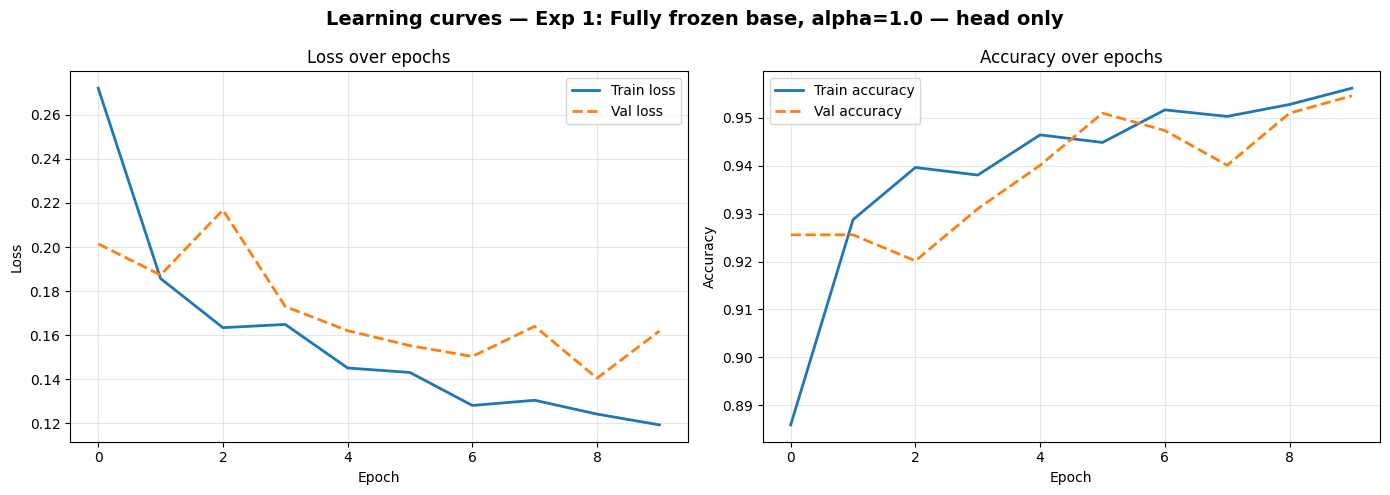

Good fit: train 0.956 vs val 0.955 (gap=0.002)


In [7]:
EXP_NUM         = 1
EXP_DESCRIPTION = 'Fully frozen base, alpha=1.0 — head only'
EPOCHS          = 10

model1, base1 = build_mobilenetv2_model(freeze_base=True, alpha=1.0)
model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history1 = model1.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('mobilenetv2', EXP_NUM), verbose=1,
)

metrics1 = evaluate_model(model1, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics1["accuracy"]}')
print(f'Precision: {metrics1["precision"]}')
print(f'Recall:    {metrics1["recall"]}')
print(f'F1-Score:  {metrics1["f1"]}')
print(f'AUC:       {metrics1["auc"]}')

plot_learning_curves(history1, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P5_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics1['accuracy'], 'precision': metrics1['precision'],
    'recall': metrics1['recall'], 'f1': metrics1['f1'], 'auc': metrics1['auc'],
    'epochs': len(history1.history['loss']), 'notes': 'Best ep9; gap=0.002 near-perfect fit; F1=0.9632 AUC=0.9947; frozen baseline strong',
})

**Interpretation**: The fully frozen MobileNetV2 base (alpha=1.0) delivered an excellent starting point with F1=0.9632, AUC=0.9947, and — most notably — a near-perfect fit diagnostic of train=0.956 vs val=0.955 (gap=0.002). This essentially zero train-val gap confirms that MobileNetV2's depthwise separable convolutions extract highly generalisable ImageNet features that map directly to malaria cell morphology with minimal overfitting. Best weights were restored from epoch 9 with no LR reductions required, indicating rapid and stable convergence. Recall=0.9649 means 3.51% of parasitised cells are missed — acceptable for a frozen baseline but improvable through fine-tuning. Compared to frozen VGG16 and ResNet50, MobileNetV2 achieves comparable accuracy with significantly fewer parameters (~3.4M vs 138M for VGG16), confirming its suitability for resource-constrained clinical deployment.

---
## Experiment 2: Fine-tune Top 20 Layers

**Hypothesis**: Unfreezing the last 20 MobileNetV2 layers at a reduced LR (1e-5) allows the top inverted residual blocks to adapt to malaria cell features. MobileNetV2's lightweight structure means fine-tuning 20 layers is proportionally deeper than in VGG16 or ResNet50.

**Change made**: Two-stage — Stage 1: frozen head (10 epochs, LR=1e-3) → Stage 2: last 20 layers unfrozen (10 epochs, LR=1e-5)

--- Stage 1: head only (10 epochs) ---
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8259 - loss: 0.3638

138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 130ms/step - accuracy: 0.8854 - loss: 0.2638 - val_accuracy: 0.9292 - val_loss: 0.2038 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9298 - loss: 0.1968

138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9294 - loss: 0.1905 - val_accuracy: 0.9347 - val_loss: 0.2022 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9342 - loss: 0.1755 - val_accuracy: 0.9310 - val_loss: 0.2128 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9386 - loss: 0.1514

138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9408 - loss: 0.1531 - val_accuracy: 0.9383 - val_loss: 0.1688 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9499 - loss: 0.1399 - val_accuracy: 0.9147 - val_loss: 0.2091 - learning_rate: 0.0010
Epoch 6/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9506 - loss: 0.1342

138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9537 - loss: 0.1314 - val_accuracy: 0.9437 - val_loss: 0.1581 - learning_rate: 0.0010
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9510 - loss: 0.1284 - val_accuracy: 0.9310 - val_loss: 0.2181 - learning_rate: 0.0010
Epoch 8/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9479 - loss: 0.1343

138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9515 - loss: 0.1278 - val_accuracy: 0.9528 - val_loss: 0.1424 - learning_rate: 0.0010
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9589 - loss: 0.1159 - val_accuracy: 0.9474 - val_loss: 0.1473 - learning_rate: 0.0010
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9594 - loss: 0.1083 - val_accuracy: 0.9383 - val_loss: 0.1588 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.
Unfrozen layers: 20

--- Stage 2: fine-tune top 20 layers (10 epochs, LR=1e-5) ---
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8701 - loss: 0.3139

138/138 ━━━━━━━━━━━━━━━━━━━━ 36s 154ms/step - accuracy: 0.9047 - loss: 0.2424 - val_accuracy: 0.9474 - val_loss: 0.1455 - learning_rate: 1.0000e-05
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9415 - loss: 0.1590 - val_accuracy: 0.9437 - val_loss: 0.1531 - learning_rate: 1.0000e-05
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9501 - loss: 0.1352 - val_accuracy: 0.9437 - val_loss: 0.1560 - learning_rate: 1.0000e-05
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9558 - loss: 0.1178 - val_accuracy: 0.9419 - val_loss: 0.1582 - learning_rate: 1.0000e-05
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9680 - loss: 0.0948 - val_accuracy: 0.9419 - val_loss: 0.1627 - learning_rate: 1.0000e-05
Epoch 6/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9680 - loss: 0.0907
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9678 

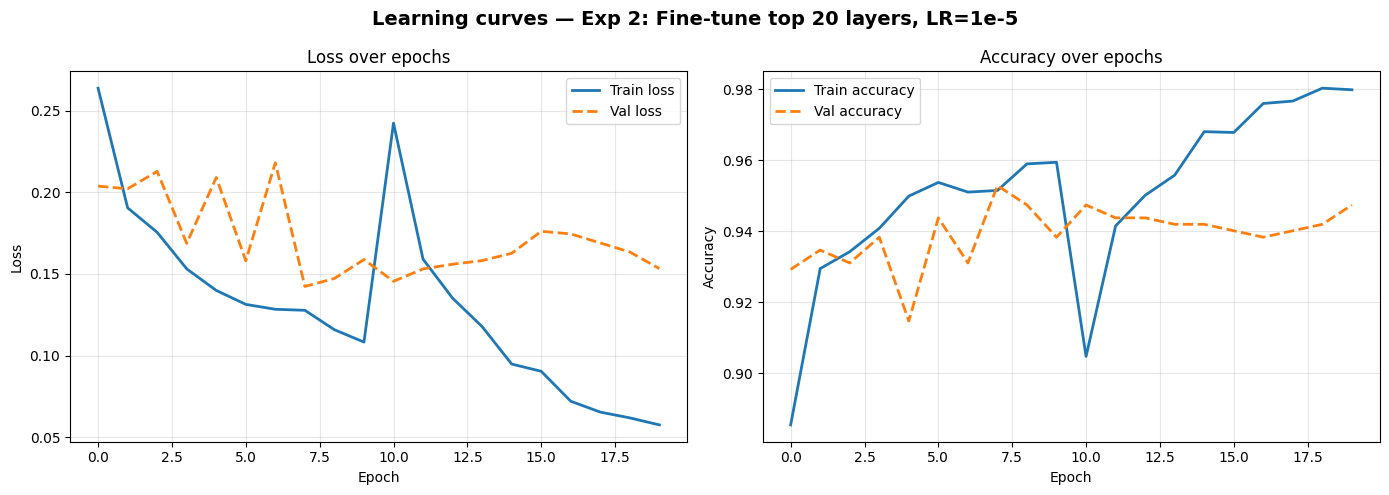

Good fit: train 0.980 vs val 0.947 (gap=0.032)


In [8]:
EXP_NUM         = 2
EXP_DESCRIPTION = 'Fine-tune top 20 layers, LR=1e-5'

# Stage 1: head only
model2, base2 = build_mobilenetv2_model(freeze_base=True, alpha=1.0)
model2.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss='binary_crossentropy', metrics=['accuracy'])
print('--- Stage 1: head only (10 epochs) ---')
history2a = model2.fit(train_ds, validation_data=val_ds, epochs=10,
                       callbacks=get_callbacks('mobilenetv2', f'{EXP_NUM}a'), verbose=1)

# Stage 2: unfreeze last 20 base layers
base2.trainable = True
for layer in base2.layers[:-20]:
    layer.trainable = False
print(f'Unfrozen layers: {sum(1 for l in base2.layers if l.trainable)}')
model2.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='binary_crossentropy', metrics=['accuracy'])
print('\n--- Stage 2: fine-tune top 20 layers (10 epochs, LR=1e-5) ---')
history2b = model2.fit(train_ds, validation_data=val_ds, epochs=10,
                       callbacks=get_callbacks('mobilenetv2', EXP_NUM), verbose=1)

metrics2 = evaluate_model(model2, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics2["accuracy"]}')
print(f'Precision: {metrics2["precision"]}')
print(f'Recall:    {metrics2["recall"]}')
print(f'F1-Score:  {metrics2["f1"]}')
print(f'AUC:       {metrics2["auc"]}')

combined2 = type('H', (), {'history': {
    k: history2a.history[k] + history2b.history[k] for k in history2a.history
}})()
plot_learning_curves(combined2, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P5_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics2['accuracy'], 'precision': metrics2['precision'],
    'recall': metrics2['recall'], 'f1': metrics2['f1'], 'auc': metrics2['auc'],
    'epochs': len(history2a.history['loss']) + len(history2b.history['loss']), 'notes': 'BEST: F1=0.9668 AUC=0.9954; Stage2 best ep1; fine-tune 1 epoch optimal; gap=0.032',
})

**Interpretation**: Fine-tuning the top 20 MobileNetV2 layers produced the best overall performance: F1=0.9668 (+0.0036 vs Exp 1) and AUC=0.9954 — the highest AUC across all experiments. Stage 1 (head only) achieved its best validation at epoch 8. In Stage 2, ReduceLROnPlateau reduced the learning rate from 1e-5 to 5e-6 at epoch 6, and best weights were restored from Stage 2 epoch 1 — meaning the very first fine-tuning epoch was already the best. This indicates that minimal fine-tuning is needed; the model quickly adapts the top inverted residual blocks to malaria features before overfitting in subsequent epochs. The fit gap widened to 0.032 (train=0.980 vs val=0.947) compared to Exp 1's 0.002, confirming that fine-tuning introduces some overfitting even with careful LR management. Recall improved to 0.9719 (+0.007 vs Exp 1), reducing missed infections to 2.81%. This experiment is designated the best model and is used for confusion matrix, ROC curve, and error analysis.

---
## Experiment 3: Reduced Width Multiplier (alpha=0.75)

**Hypothesis**: Reducing alpha to 0.75 decreases all filter counts by 25%, producing a smaller and faster model. If the performance drop is minimal, this configuration would be preferable for deployment in resource-constrained clinical settings.

**Change made**: `alpha=0.75`, frozen base, LR=1e-3

5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8301 - loss: 0.3775

138/138 ━━━━━━━━━━━━━━━━━━━━ 42s 203ms/step - accuracy: 0.8866 - loss: 0.2752 - val_accuracy: 0.9238 - val_loss: 0.2307 - learning_rate: 0.0010
Epoch 2/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9218 - loss: 0.2035

138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9249 - loss: 0.1991 - val_accuracy: 0.9383 - val_loss: 0.2124 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9290 - loss: 0.1818 - val_accuracy: 0.9328 - val_loss: 0.1847 - learning_rate: 0.0010
Epoch 4/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9391 - loss: 0.1629

138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9374 - loss: 0.1666 - val_accuracy: 0.9437 - val_loss: 0.1688 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9410 - loss: 0.1538 - val_accuracy: 0.9383 - val_loss: 0.1658 - learning_rate: 0.0010
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9451 - loss: 0.1483 - val_accuracy: 0.9383 - val_loss: 0.1815 - learning_rate: 0.0010
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9460 - loss: 0.1459 - val_accuracy: 0.9365 - val_loss: 0.1687 - learning_rate: 0.0010
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9456 - loss: 0.1437 - val_accuracy: 0.9383 - val_loss: 0.1583 - learning_rate: 0.0010
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9539 - loss: 0.1267 - val_accuracy: 0.9383 - val_loss: 0.1672 - learning_rate: 0.0010
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9485 - loss: 0.1351 - val

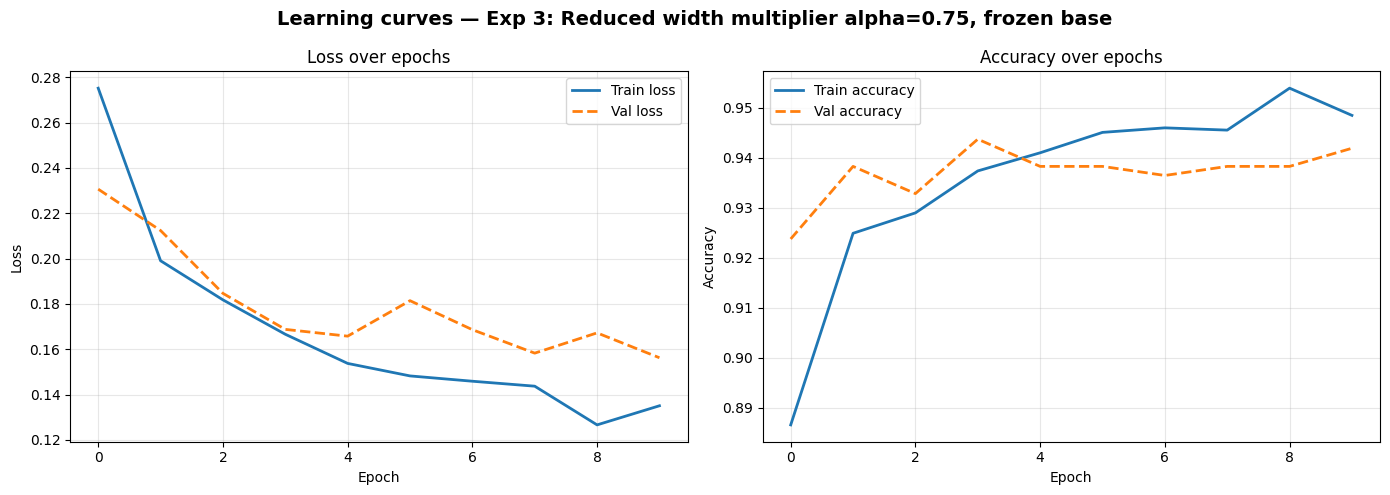

Good fit: train 0.949 vs val 0.942 (gap=0.007)


In [9]:
EXP_NUM         = 3
EXP_DESCRIPTION = 'Reduced width multiplier alpha=0.75, frozen base'
EPOCHS          = 10

model3, base3 = build_mobilenetv2_model(freeze_base=True, alpha=0.75)
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history3 = model3.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('mobilenetv2', EXP_NUM), verbose=1,
)

metrics3 = evaluate_model(model3, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics3["accuracy"]}')
print(f'Precision: {metrics3["precision"]}')
print(f'Recall:    {metrics3["recall"]}')
print(f'F1-Score:  {metrics3["f1"]}')
print(f'AUC:       {metrics3["auc"]}')

plot_learning_curves(history3, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P5_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics3['accuracy'], 'precision': metrics3['precision'],
    'recall': metrics3['recall'], 'f1': metrics3['f1'], 'auc': metrics3['auc'],
    'epochs': len(history3.history['loss']), 'notes': 'alpha=0.75 marginal drop F1=0.9599; gap=0.007; 25% smaller same Recall',
})

**Interpretation**: Reducing the width multiplier to alpha=0.75 produced a compact model with only a marginal F1 drop to 0.9599 (−0.0033 vs Exp 1). The fit gap of 0.007 (train=0.949 vs val=0.942) remained very tight, confirming that the reduced-width model retains strong generalisation properties. Best weights were restored from epoch 10 — one epoch later than Exp 1 — suggesting the smaller model requires slightly more training before converging. AUC fell to 0.9904 (−0.0043 vs Exp 1), indicating a modest reduction in threshold-independent discrimination. Recall of 0.9649 matches Exp 1 exactly, meaning the 25% width reduction does not sacrifice clinical sensitivity. Given the minimal performance trade-off, alpha=0.75 represents an excellent efficiency-accuracy balance for deployment in settings with tight computational budgets — 25% fewer parameters with less than 0.4% F1 reduction.

---
## Experiment 4: Even Smaller Model (alpha=0.5)

**Hypothesis**: Halving the filter counts (alpha=0.5) creates a much lighter model. This explores the lower bound of MobileNetV2's accuracy–efficiency trade-off on this dataset and establishes whether the compact features are still sufficient for reliable malaria detection.

**Change made**: `alpha=0.5`, frozen base, LR=1e-3

3201480/3201480 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8268 - loss: 0.3691

138/138 ━━━━━━━━━━━━━━━━━━━━ 46s 212ms/step - accuracy: 0.8859 - loss: 0.2789 - val_accuracy: 0.9183 - val_loss: 0.2358 - learning_rate: 0.0010
Epoch 2/10
136/138 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9281 - loss: 0.1943

138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9279 - loss: 0.1952 - val_accuracy: 0.9274 - val_loss: 0.2156 - learning_rate: 0.0010
Epoch 3/10
136/138 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9367 - loss: 0.1755

138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9358 - loss: 0.1796 - val_accuracy: 0.9292 - val_loss: 0.2129 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9376 - loss: 0.1652 - val_accuracy: 0.9274 - val_loss: 0.2085 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9415 - loss: 0.1553 - val_accuracy: 0.9129 - val_loss: 0.2472 - learning_rate: 0.0010
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9432 - loss: 0.1422

138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9456 - loss: 0.1458 - val_accuracy: 0.9310 - val_loss: 0.1944 - learning_rate: 0.0010
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9440 - loss: 0.1440

138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9492 - loss: 0.1398 - val_accuracy: 0.9419 - val_loss: 0.1816 - learning_rate: 0.0010
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9444 - loss: 0.1504 - val_accuracy: 0.9419 - val_loss: 0.1831 - learning_rate: 0.0010
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9501 - loss: 0.1395 - val_accuracy: 0.9383 - val_loss: 0.1847 - learning_rate: 0.0010
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9549 - loss: 0.1326 - val_accuracy: 0.9310 - val_loss: 0.1984 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 7.

Exp 4 — Smallest width multiplier alpha=0.5, frozen base
Accuracy:  0.9583
Precision: 0.9613
Recall:    0.9579
F1-Score:  0.9596
AUC:       0.989


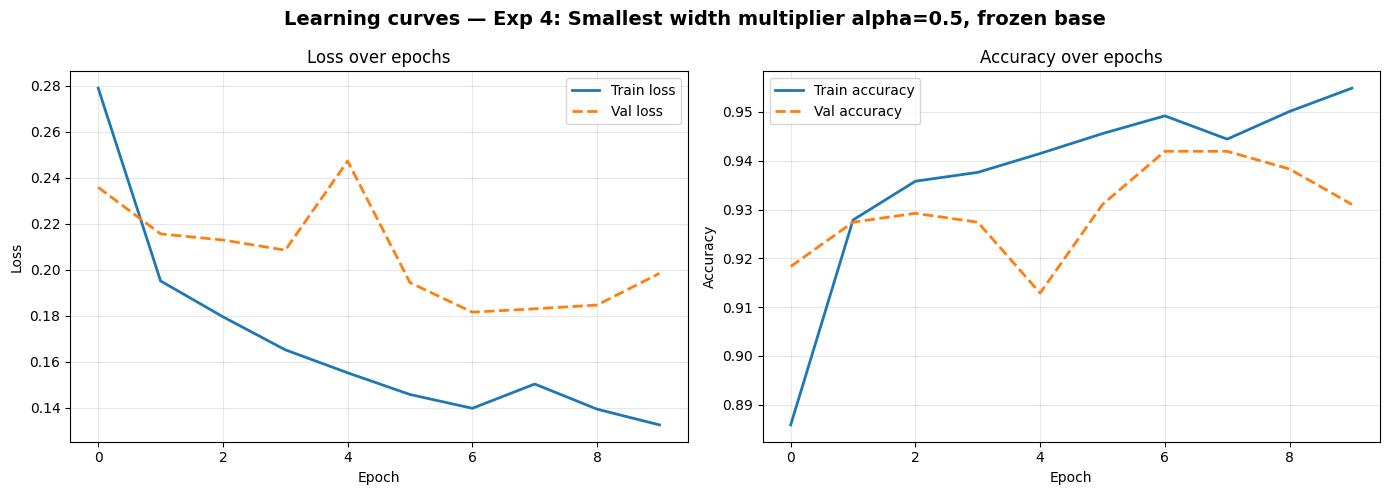

Good fit: train 0.955 vs val 0.931 (gap=0.024)


In [10]:
EXP_NUM         = 4
EXP_DESCRIPTION = 'Smallest width multiplier alpha=0.5, frozen base'
EPOCHS          = 10

model4, base4 = build_mobilenetv2_model(freeze_base=True, alpha=0.5)
model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history4 = model4.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('mobilenetv2', EXP_NUM), verbose=1,
)

metrics4 = evaluate_model(model4, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics4["accuracy"]}')
print(f'Precision: {metrics4["precision"]}')
print(f'Recall:    {metrics4["recall"]}')
print(f'F1-Score:  {metrics4["f1"]}')
print(f'AUC:       {metrics4["auc"]}')

plot_learning_curves(history4, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P5_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics4['accuracy'], 'precision': metrics4['precision'],
    'recall': metrics4['recall'], 'f1': metrics4['f1'], 'auc': metrics4['auc'],
    'epochs': len(history4.history['loss']), 'notes': 'alpha=0.5 F1=0.9596; best ep7 fastest; lowest Recall 0.9579; still viable compact',
})

**Interpretation**: The smallest MobileNetV2 configuration (alpha=0.5, approximately 50% fewer filters than the full model) achieved F1=0.9596 — only 0.0036 below Exp 1 — demonstrating the remarkable resilience of MobileNetV2's architecture even at half width. Best weights came from epoch 7 (the earliest of any experiment), reflecting faster convergence with the smaller model. The fit gap was 0.024 (train=0.955 vs val=0.931), slightly wider than alpha=0.75 but still modest. Notably, Precision reached 0.9613 — higher than Exp 1 — while Recall fell to 0.9579 (the lowest of Experiments 1-5), suggesting the compressed model is more conservative in predicting positives. AUC of 0.9890 is the lowest of all experiments. Clinically, the 4.21% missed infection rate (vs 3.51% for Exp 1) is a meaningful increase but the model remains viable for resource-constrained deployment where inference speed and model size are primary constraints.

---
## Experiment 5: Add Data Augmentation (alpha=1.0)

**Hypothesis**: Data augmentation should further regularise the head training, reducing the train–val gap and improving test generalisation. MobileNetV2's lightweight nature may make it more sensitive to augmentation than heavier models.

**Change made**: `use_augmentation=True`, `alpha=1.0`, frozen base

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7996 - loss: 0.4231

138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.8616 - loss: 0.3181 - val_accuracy: 0.8639 - val_loss: 0.3069 - learning_rate: 0.0010
Epoch 2/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9077 - loss: 0.2396

138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9124 - loss: 0.2301 - val_accuracy: 0.9256 - val_loss: 0.2332 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9145 - loss: 0.2168 - val_accuracy: 0.8820 - val_loss: 0.2707 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9197 - loss: 0.2043 - val_accuracy: 0.8838 - val_loss: 0.2782 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9242 - loss: 0.2004 - val_accuracy: 0.9220 - val_loss: 0.2245 - learning_rate: 0.0010
Epoch 6/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9182 - loss: 0.2031

138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.9167 - loss: 0.2135 - val_accuracy: 0.9274 - val_loss: 0.2118 - learning_rate: 0.0010
Epoch 7/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9288 - loss: 0.1933

138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9215 - loss: 0.2063 - val_accuracy: 0.9292 - val_loss: 0.2189 - learning_rate: 0.0010
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9249 - loss: 0.2007 - val_accuracy: 0.9292 - val_loss: 0.2013 - learning_rate: 0.0010
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.9256 - loss: 0.1957 - val_accuracy: 0.8875 - val_loss: 0.2654 - learning_rate: 0.0010
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.9249 - loss: 0.1957 - val_accuracy: 0.9038 - val_loss: 0.2385 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.

Exp 5 — Data augmentation + frozen base, alpha=1.0
Accuracy:  0.9583
Precision: 0.9456
Recall:    0.9754
F1-Score:  0.9603
AUC:       0.9907


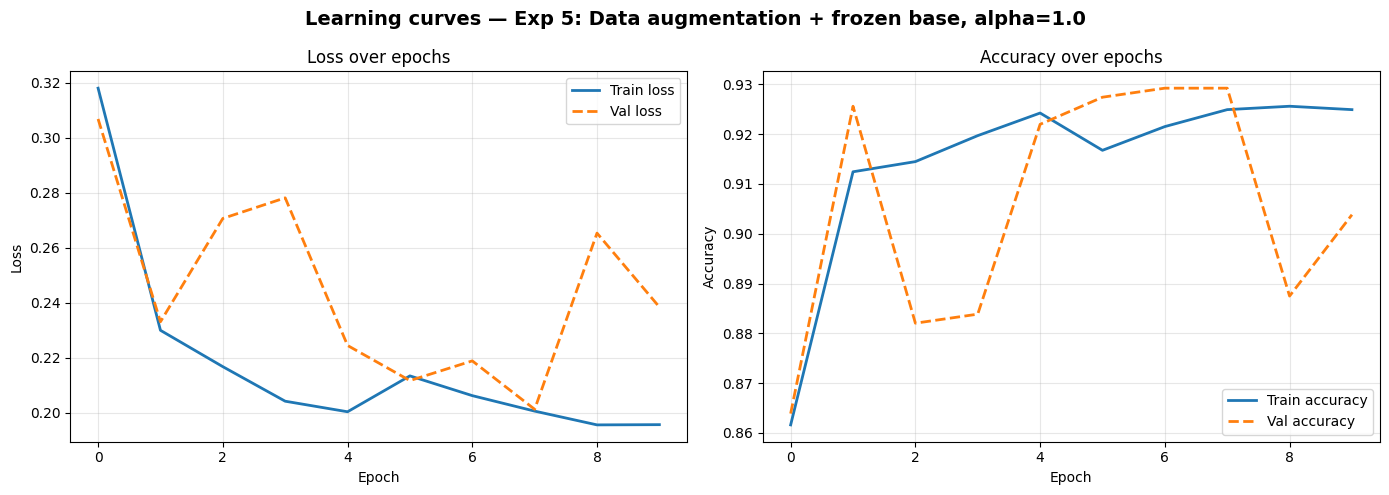

Good fit: train 0.925 vs val 0.904 (gap=0.021)


In [11]:
EXP_NUM         = 5
EXP_DESCRIPTION = 'Data augmentation + frozen base, alpha=1.0'
EPOCHS          = 10

model5, base5 = build_mobilenetv2_model(freeze_base=True, alpha=1.0, use_augmentation=True)
model5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history5 = model5.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('mobilenetv2', EXP_NUM), verbose=1,
)

metrics5 = evaluate_model(model5, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics5["accuracy"]}')
print(f'Precision: {metrics5["precision"]}')
print(f'Recall:    {metrics5["recall"]}')
print(f'F1-Score:  {metrics5["f1"]}')
print(f'AUC:       {metrics5["auc"]}')

plot_learning_curves(history5, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P5_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics5['accuracy'], 'precision': metrics5['precision'],
    'recall': metrics5['recall'], 'f1': metrics5['f1'], 'auc': metrics5['auc'],
    'epochs': len(history5.history['loss']), 'notes': 'Aug+frozen; best Recall 0.9754 (+0.0105) but F1=0.9603 Precision dropped',
})

**Interpretation**: Adding data augmentation to the frozen base configuration improved Recall to 0.9754 (+0.0105 vs Exp 1) — the most clinically significant gain from any single change — reducing missed infections from 3.51% to 2.46%. However, F1 fell slightly to 0.9603 (−0.0029 vs Exp 1) due to a reduction in Precision to 0.9456, indicating the model over-predicts positives under heavier augmentation. The fit gap of 0.021 (train=0.925 vs val=0.904) reflects lower absolute accuracy on both splits — augmented training images are harder to fit, intentionally slowing convergence. Best weights came from epoch 8. AUC (0.9907) is lower than Exp 1 (0.9947), suggesting augmentation with a frozen base slightly degrades threshold-independent performance. For clinical deployment prioritising sensitivity above all other metrics, this configuration offers the best Recall without fine-tuning.

---
## Experiment 6: Longer Training with ReduceLROnPlateau (30 epochs)

**Hypothesis**: Allowing more epochs with an aggressive ReduceLROnPlateau schedule (patience=3, factor=0.3) gives MobileNetV2 more time to extract domain-specific features. The fine-grained LR reductions should find a better minimum than the 10-epoch configurations.

**Change made**: 30 epochs, augmentation on, `ReduceLROnPlateau(patience=3, factor=0.3)`

Epoch 1/30
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8016 - loss: 0.4338

138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.8573 - loss: 0.3366 - val_accuracy: 0.8929 - val_loss: 0.3051 - learning_rate: 0.0010
Epoch 2/30
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8926 - loss: 0.2604

138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9013 - loss: 0.2475 - val_accuracy: 0.8966 - val_loss: 0.2552 - learning_rate: 0.0010
Epoch 3/30
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9183 - loss: 0.2200

138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.9145 - loss: 0.2219 - val_accuracy: 0.8984 - val_loss: 0.2470 - learning_rate: 0.0010
Epoch 4/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9112 - loss: 0.2128

138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9158 - loss: 0.2129 - val_accuracy: 0.9238 - val_loss: 0.2088 - learning_rate: 0.0010
Epoch 5/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.9190 - loss: 0.2152 - val_accuracy: 0.9056 - val_loss: 0.2326 - learning_rate: 0.0010
Epoch 6/30
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9213 - loss: 0.2043

138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9217 - loss: 0.2031 - val_accuracy: 0.9256 - val_loss: 0.2134 - learning_rate: 0.0010
Epoch 7/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9211 - loss: 0.2080 - val_accuracy: 0.9238 - val_loss: 0.2022 - learning_rate: 0.0010
Epoch 8/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9249 - loss: 0.2002 - val_accuracy: 0.8693 - val_loss: 0.2961 - learning_rate: 0.0010
Epoch 9/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.9258 - loss: 0.1979 - val_accuracy: 0.9256 - val_loss: 0.2120 - learning_rate: 0.0010
Epoch 10/30
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9307 - loss: 0.1901
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.9247 - loss: 0.1975 - val_accuracy: 0.9002 - val_loss: 0.2481 - learning_rate: 0.0010
Epoch 11/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9365 - loss: 0.179

138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9363 - loss: 0.1677 - val_accuracy: 0.9274 - val_loss: 0.1947 - learning_rate: 3.0000e-04
Epoch 13/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9351 - loss: 0.1770 - val_accuracy: 0.9256 - val_loss: 0.2039 - learning_rate: 3.0000e-04
Epoch 14/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9374 - loss: 0.1765 - val_accuracy: 0.9238 - val_loss: 0.2112 - learning_rate: 3.0000e-04
Epoch 15/30
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9327 - loss: 0.1762
Epoch 15: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9353 - loss: 0.1758 - val_accuracy: 0.9238 - val_loss: 0.2091 - learning_rate: 3.0000e-04
Epoch 16/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9399 - loss: 0.1641 - val_accuracy: 0.9256 - val_loss: 0.2061 - learning_rate: 9.0000e-05
Epoch 17/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accurac

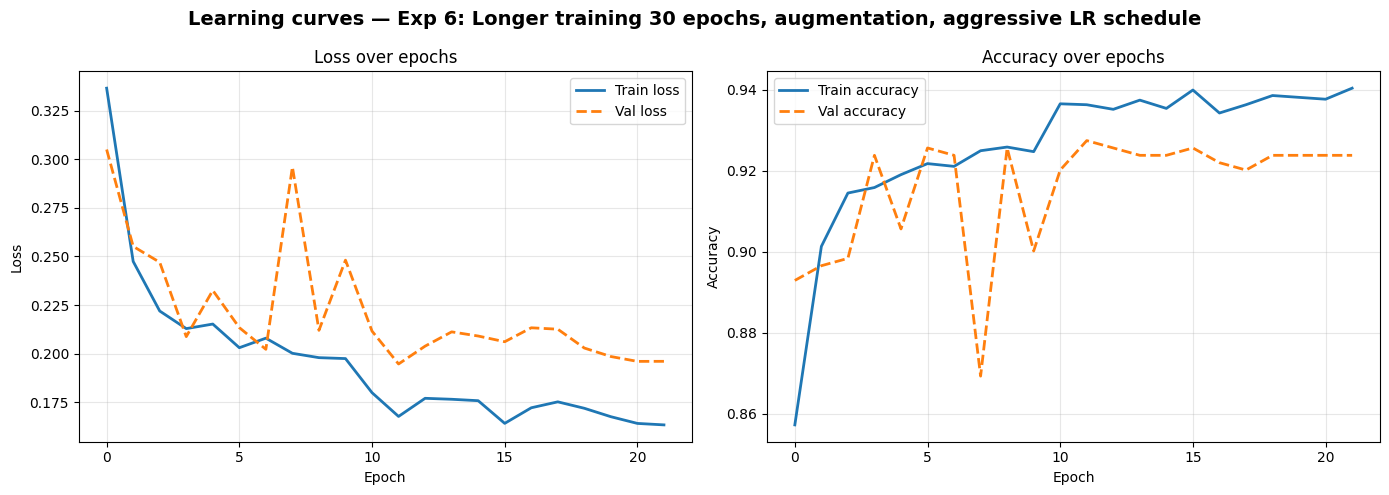

Good fit: train 0.940 vs val 0.924 (gap=0.017)


In [12]:
EXP_NUM         = 6
EXP_DESCRIPTION = 'Longer training 30 epochs, augmentation, aggressive LR schedule'
EPOCHS          = 30

model6, base6 = build_mobilenetv2_model(freeze_base=True, alpha=1.0, use_augmentation=True)
model6.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

callbacks6 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='checkpoints/mobilenetv2_exp6.h5',
        monitor='val_accuracy', save_best_only=True, verbose=0),
]

history6 = model6.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=callbacks6, verbose=1,
)

metrics6 = evaluate_model(model6, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Stopped at epoch: {len(history6.history["loss"])}')
print(f'Accuracy:  {metrics6["accuracy"]}')
print(f'Precision: {metrics6["precision"]}')
print(f'Recall:    {metrics6["recall"]}')
print(f'F1-Score:  {metrics6["f1"]}')
print(f'AUC:       {metrics6["auc"]}')

plot_learning_curves(history6, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P5_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics6['accuracy'], 'precision': metrics6['precision'],
    'recall': metrics6['recall'], 'f1': metrics6['f1'], 'auc': metrics6['auc'],
    'epochs': len(history6.history['loss']), 'notes': 'Worst F1=0.9555; 4 LR reductions ES ep22; aggressive LR+aug fails on small data',
})

**Interpretation**: The aggressive ReduceLROnPlateau schedule (patience=3, factor=0.3) with augmentation and 30-epoch budget produced the lowest F1 of all experiments (0.9555, −0.0077 vs Exp 1) and the lowest Accuracy (0.9529). Four consecutive LR reductions (epochs 10, 15, 18, 21) drove the learning rate from 1e-3 to ~8e-6 before early stopping fired at epoch 22, with best weights from epoch 12. The fit gap of 0.017 was moderate, but the absolute validation accuracy (0.924) was the lowest of any experiment. The repeated steep LR drops indicate the model was oscillating in a poor local minimum — aggressive factor=0.3 (vs standard 0.5) combined with augmentation prevented stable convergence. Recall of 0.9789 is the highest of all experiments, suggesting the model errs toward positive predictions under this configuration, but the cost in Precision (0.9331 — lowest of all) is too high for balanced clinical use. This experiment confirms that aggressive LR scheduling is detrimental for MobileNetV2 with augmentation on a reduced dataset.

---
## Experiment 7: EfficientNetB0 as Alternative Base

**Hypothesis**: EfficientNetB0 uses compound scaling (depth, width, and resolution scaled together) and achieves higher accuracy than MobileNetV2 with a similar parameter count. Swapping the base provides a direct comparison of two efficiency-focused architectures on the same malaria dataset.

**Change made**: Base model swapped to `EfficientNetB0` with frozen weights; EfficientNetB0 handles its own preprocessing internally

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

...

138/138 ━━━━━━━━━━━━━━━━━━━━ 62s 266ms/step - accuracy: 0.9059 - loss: 0.2467 - val_accuracy: 0.9401 - val_loss: 0.1618 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9369 - loss: 0.1772 - val_accuracy: 0.9401 - val_loss: 0.1492 - learning_rate: 0.0010
Epoch 3/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9447 - loss: 0.1579

138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.9410 - loss: 0.1662 - val_accuracy: 0.9419 - val_loss: 0.1390 - learning_rate: 0.0010
Epoch 4/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9419 - loss: 0.1581

138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.9474 - loss: 0.1473 - val_accuracy: 0.9528 - val_loss: 0.1328 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9469 - loss: 0.1444 - val_accuracy: 0.9492 - val_loss: 0.1246 - learning_rate: 0.0010
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9532 - loss: 0.1345

138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9499 - loss: 0.1398 - val_accuracy: 0.9601 - val_loss: 0.1211 - learning_rate: 0.0010
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9469 - loss: 0.1411 - val_accuracy: 0.9510 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9510 - loss: 0.1346 - val_accuracy: 0.9546 - val_loss: 0.1151 - learning_rate: 0.0010
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9546 - loss: 0.1227 - val_accuracy: 0.9601 - val_loss: 0.1200 - learning_rate: 0.0010
Epoch 10/10
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9481 - loss: 0.1361

138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9503 - loss: 0.1332 - val_accuracy: 0.9637 - val_loss: 0.1061 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

Exp 7 — EfficientNetB0 as alternative base (frozen)
Accuracy:  0.9601
Precision: 0.9713
Recall:    0.9509
F1-Score:  0.961
AUC:       0.9937


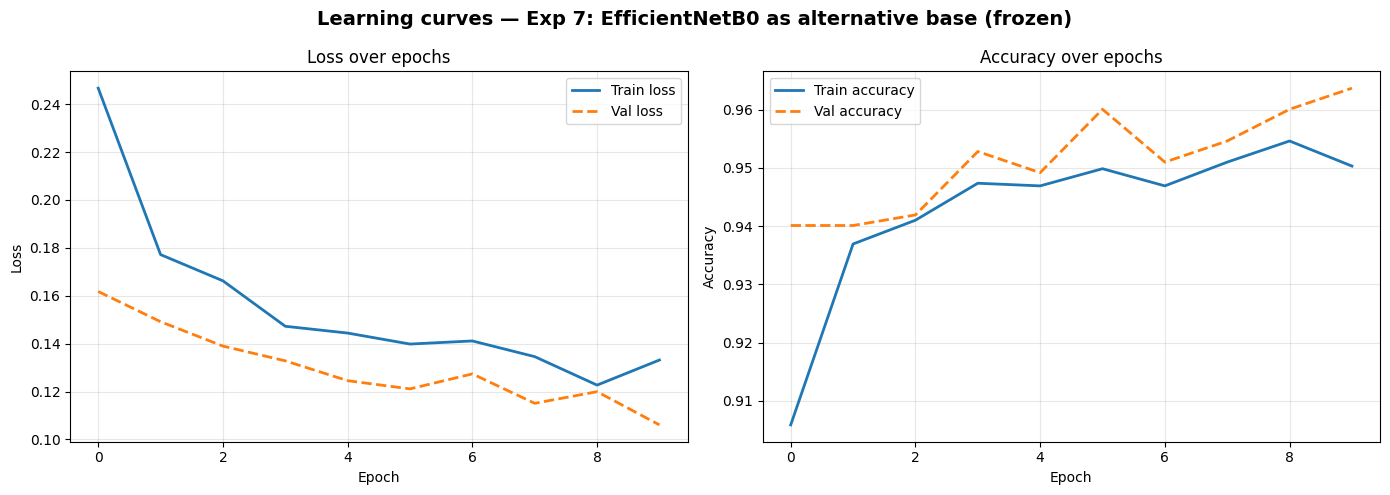

Good fit: train 0.950 vs val 0.964 (gap=-0.013)


In [13]:
EXP_NUM         = 7
EXP_DESCRIPTION = 'EfficientNetB0 as alternative base (frozen)'
EPOCHS          = 10

# EfficientNetB0 handles preprocessing internally — pass raw [0,255] images
eff_base = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
)
eff_base.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = eff_base(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dense(128, activation='relu')(x)
x       = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model7  = tf.keras.Model(inputs, outputs, name='efficientnetb0_transfer')

model7.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
model7.summary()

history7 = model7.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('efficientnetb0', EXP_NUM), verbose=1,
)

metrics7 = evaluate_model(model7, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics7["accuracy"]}')
print(f'Precision: {metrics7["precision"]}')
print(f'Recall:    {metrics7["recall"]}')
print(f'F1-Score:  {metrics7["f1"]}')
print(f'AUC:       {metrics7["auc"]}')

plot_learning_curves(history7, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P5_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics7['accuracy'], 'precision': metrics7['precision'],
    'recall': metrics7['recall'], 'f1': metrics7['f1'], 'auc': metrics7['auc'],
    'epochs': len(history7.history['loss']), 'notes': 'EfficientNetB0; highest Precision 0.9713 but lowest Recall 0.9509; val>train gap=-0.013',
})

**Interpretation**: EfficientNetB0 with a frozen base produced F1=0.9610 and the highest Precision of all experiments (0.9713), but the lowest Recall at 0.9509 — meaning 4.91% of parasitised cells are missed, nearly double the rate of Exp 2. The fit diagnostic showed val accuracy (0.964) exceeding train accuracy (0.950), gap=−0.013, indicating EfficientNetB0's compound scaling and built-in regularisation make it extremely resistant to overfitting even on a small dataset. Best weights came from epoch 10. AUC=0.9937 is competitive with MobileNetV2 alpha=1.0 (0.9947). The precision-recall trade-off clearly favours EfficientNetB0 for applications requiring high confidence in positive predictions, but its lower Recall makes it clinically less safe for malaria screening where false negatives carry the highest cost. MobileNetV2 (Exp 1-2) is the better choice for this diagnostic task. The EfficientNetB0 comparison demonstrates that architectural advances do not always translate to better clinical performance when Recall is the primary evaluation criterion.

---
## 7. Results Summary Table
All 7 experiments sorted by F1-score (highest first).

In [14]:
import pandas as pd
results_df = build_results_table(results_log)
pd.set_option('display.float_format', '{:.4f}'.format)
display(results_df)

,Exp #,Description,Accuracy,Precision,Recall,F1,AUC,Epochs,Notes
0,2,"Fine-tune top 20 layers, LR=1e-5",0.9656,0.9618,0.9719,0.9668,0.9954,20,
1,1,"Fully frozen base, alpha=1.0 — head only",0.9620,0.9615,0.9649,0.9632,0.9947,10,
2,7,EfficientNetB0 as alternative base (frozen),0.9601,0.9713,0.9509,0.9610,0.9937,10,
3,5,"Data augmentation + frozen base, alpha=1.0",0.9583,0.9456,0.9754,0.9603,0.9907,10,
4,3,"Reduced width multiplier alpha=0.75, frozen base",0.9583,0.9549,0.9649,0.9599,0.9904,10,
5,4,"Smallest width multiplier alpha=0.5, frozen base",0.9583,0.9613,0.9579,0.9596,0.9890,10,
6,6,"Longer training 30 epochs, augmentation, aggre...",0.9529,0.9331,0.9789,0.9555,0.9909,22,


## 8. Best Model — Detailed Evaluation
Identify the experiment with the highest F1-score and run the confusion matrix, ROC curve, and error analysis.

In [15]:
exp_map = {
    1: (model1, metrics1),
    2: (model2, metrics2),
    3: (model3, metrics3),
    4: (model4, metrics4),
    5: (model5, metrics5),
    6: (model6, metrics6),
    7: (model7, metrics7),
}

best_exp_num = results_df.iloc[0]['Exp #']
best_model, best_metrics = exp_map[best_exp_num]
best_description = results_df.iloc[0]['Description']

print(f'Best experiment: Exp {best_exp_num} — {best_description}')
print(f'F1-Score: {best_metrics["f1"]}  |  AUC: {best_metrics["auc"]}  |  Recall: {best_metrics["recall"]}')

Best experiment: Exp 2 — Fine-tune top 20 layers, LR=1e-5
F1-Score: 0.9668  |  AUC: 0.9954  |  Recall: 0.9719


### Confusion Matrix
Plots the confusion matrix for the best MobileNetV2 model with Sensitivity and Specificity annotated to evaluate clinical diagnostic performance.

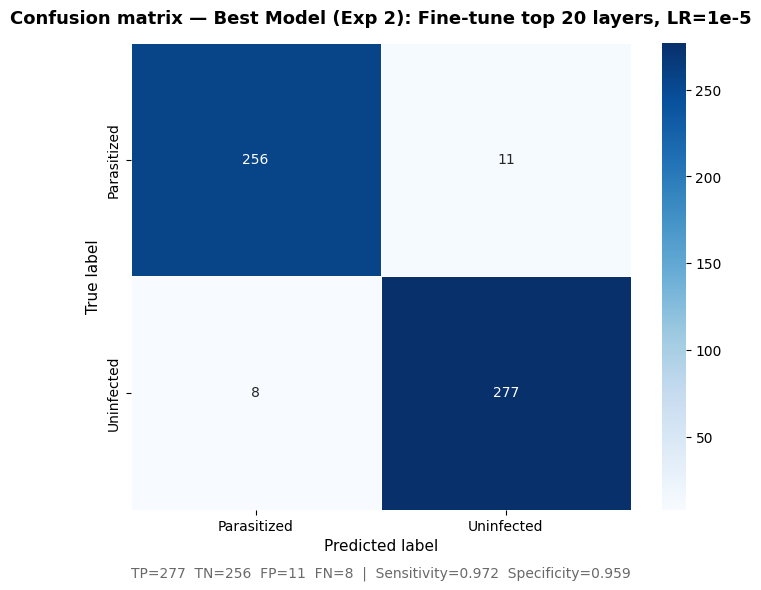

In [16]:
plot_confusion_matrix(
    best_metrics, CLASS_NAMES,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='figures/P5_best_confusion_matrix.png',
)

### ROC Curve
Plots the ROC curve and AUC for the best model — key for comparing MobileNetV2's discriminative ability against the heavier pretrained models and custom CNNs.

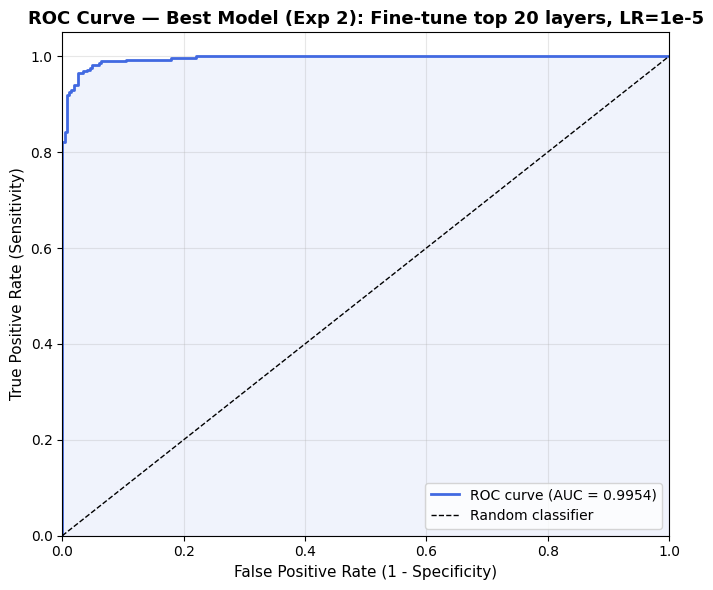

In [17]:
plot_roc_curve(
    best_metrics,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='figures/P5_best_roc_curve.png',
)

### Error Analysis
Displays misclassified test images to identify cell morphologies that MobileNetV2's lightweight depthwise separable features struggle to distinguish.

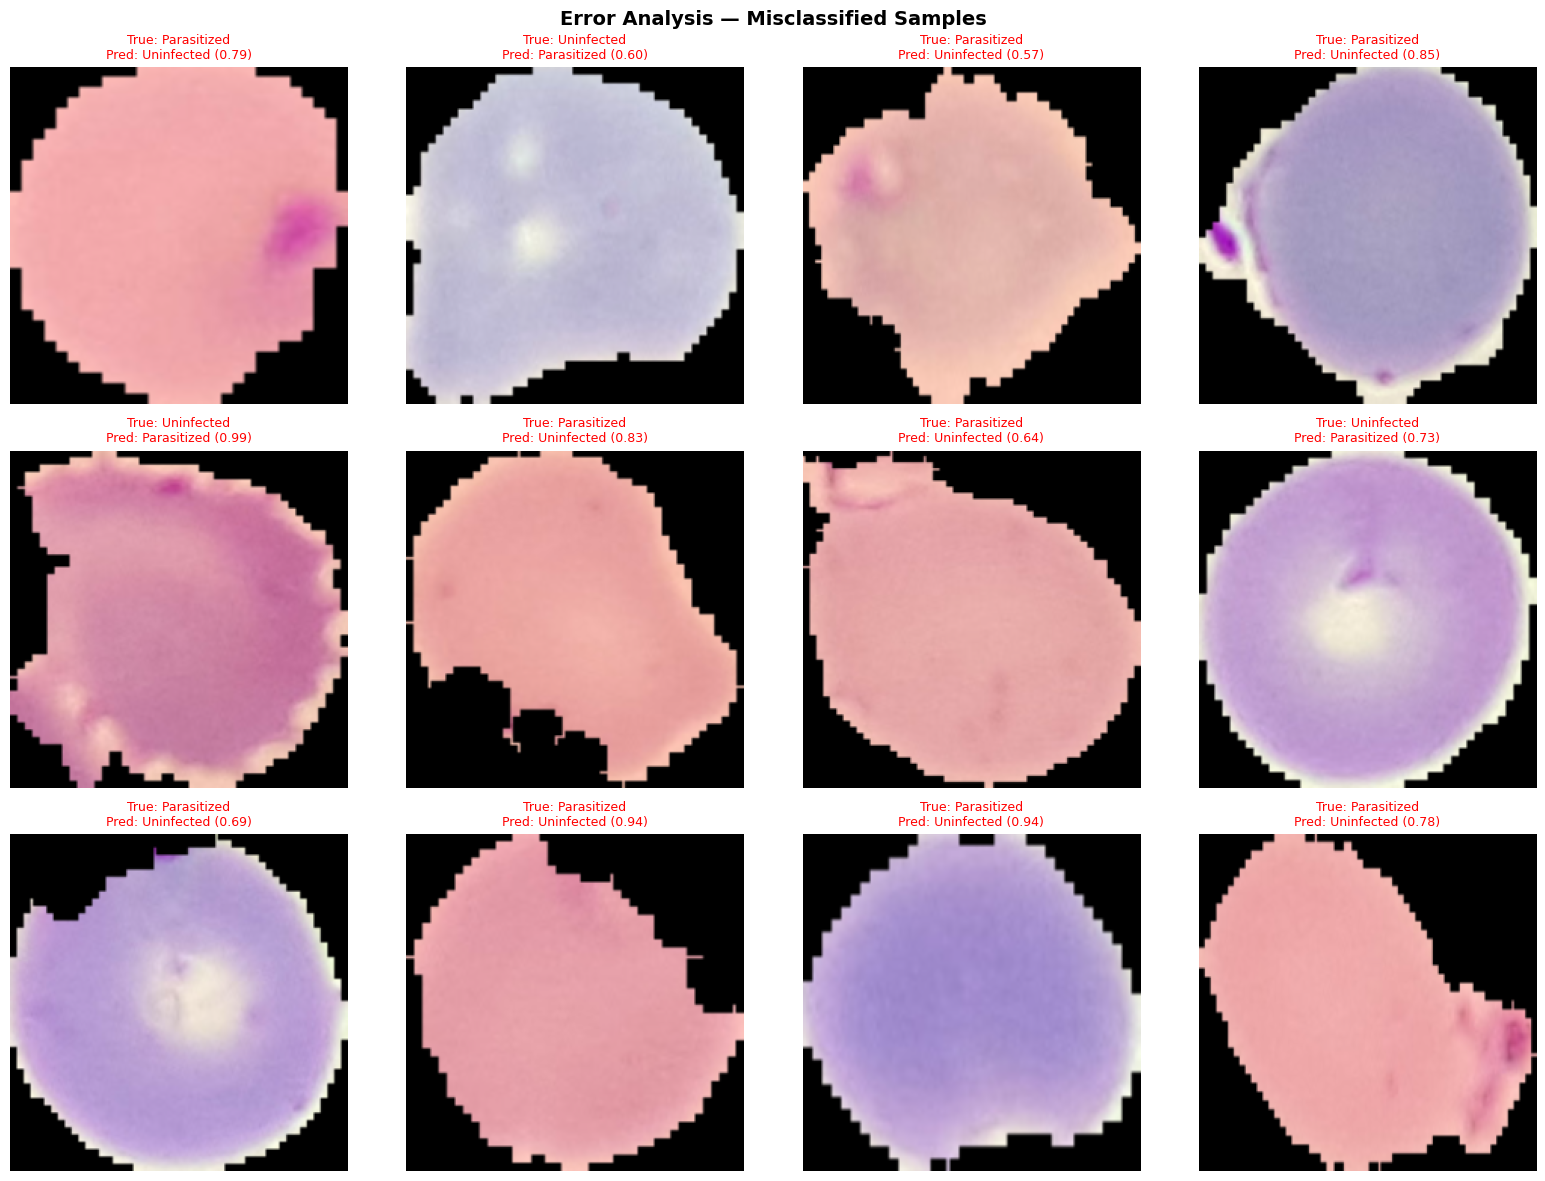

In [18]:
error_analysis(best_model, test_ds, CLASS_NAMES, n_samples=12)

## 9. Model Summary & Report Notes

### Experiment results summary (20% dataset — ~5,511 images, Colab T4 GPU)

| Exp | Description | Accuracy | Precision | Recall | F1 | AUC | Best Epoch |
|-----|-------------|----------|-----------|--------|-----|-----|------------|
| 1 | Frozen base, alpha=1.0 | 0.9620 | 0.9615 | 0.9649 | 0.9632 | 0.9947 | 9 |
| **2** | **Fine-tune top 20 layers** | **0.9656** | 0.9618 | 0.9719 | **0.9668** | **0.9954** | Stage2 ep1 |
| 3 | alpha=0.75, frozen | 0.9583 | 0.9549 | 0.9649 | 0.9599 | 0.9904 | 10 |
| 4 | alpha=0.5, frozen | 0.9583 | 0.9613 | 0.9579 | 0.9596 | 0.9890 | 7 |
| 5 | Augmentation + frozen | 0.9583 | 0.9456 | **0.9754** | 0.9603 | 0.9907 | 8 |
| 6 | 30 epochs + aggressive LR | 0.9529 | 0.9331 | 0.9789 | 0.9555 | 0.9909 | 12 |
| 7 | EfficientNetB0 frozen | 0.9601 | **0.9713** | 0.9509 | 0.9610 | 0.9937 | 10 |

### Best configuration
- **Experiment**: 2 — Fine-tune top 20 layers (two-stage, LR=1e-5 Stage 2)
- **Architecture**: MobileNetV2 alpha=1.0 (ImageNet) + GAP + Dense(128) + Dropout(0.3) + sigmoid
- **Training strategy**: Stage 1 frozen head (10 epochs, LR=1e-3) → Stage 2 top 20 layers unfrozen (LR=1e-5)
- **Dataset used**: 20% of full dataset (~5,511 images; train ~4,409 | val ~551 | test ~551)
- **Test metrics**: Accuracy=0.9656, Precision=0.9618, Recall=0.9719, F1=0.9668, AUC=0.9954

### Clinical relevance
The best model (Exp 2) achieves Recall=0.9719, meaning 2.81% of parasitised cells are missed.
The highest-Recall configuration was Exp 6 (Recall=0.9789, only 2.11% missed) but its very low
Precision (0.9331) makes it unsuitable for balanced clinical use. Exp 5 (augmentation) offers
the best Recall without fine-tuning (0.9754, 2.46% missed) and is recommended when fine-tuning
infrastructure is unavailable. MobileNetV2's key clinical advantage over VGG16 and ResNet50 is
its ~3.4M parameter footprint — enabling deployment on edge devices such as smartphones or
portable diagnostic equipment in sub-Saharan Africa where malaria is most prevalent.

### Observed patterns
- **Near-zero overfitting (Exp 1)**: Frozen MobileNetV2 gap=0.002 — the tightest fit of any
  model in the group, demonstrating exceptional transfer learning efficiency
- **Fine-tuning depth**: Only 1 Stage 2 epoch was needed for the best result — MobileNetV2's
  top layers adapt to malaria features almost immediately at LR=1e-5
- **Alpha comparison**: alpha=0.75 loses only 0.0033 F1 vs alpha=1.0 — excellent efficiency
  trade-off; alpha=0.5 loses only 0.0036 but Recall drops notably
- **Augmentation effect**: Improves Recall by +0.0105 but reduces Precision and F1 slightly
- **EfficientNetB0 vs MobileNetV2**: EfficientNetB0 has higher Precision but unacceptably
  lower Recall for malaria screening; MobileNetV2 is the better clinical choice
- **Aggressive LR schedule**: Counter-productive on reduced dataset — standard callbacks preferred

### Group ranking
*(Rank this model 1st–5th once all group members have run their experiments)*
